## A01 - Simple usage of pretrained SatCLIP embeddings

To obtained pretrained **SatCLIP** embeddings, first install the repository.

In [ ]:
!rm -r sample_data .config # Empty current directory
!git clone https://github.com/microsoft/satclip.git . # Clone SatCLIP repository

Cloning into '.'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 131 (delta 14), reused 16 (delta 4), pack-reused 95
Receiving objects: 100% (131/131), 9.01 MiB | 21.25 MiB/s, done.
Resolving deltas: 100% (48/48), done.


Now install the required Python packages.

In [ ]:
!pip install lightning --quiet
!pip install rasterio --quiet
!pip install torchgeo --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.1/806.1 kB 40.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.9/776.9 kB 42.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 27.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.5/378.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 705.7/705.7 kB 37.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.7/670.7 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 41.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 66.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━

You can find a list of pretrained SatCLIP models [here](https://github.com/microsoft/satclip#pretrained-models). Let's download a SatCLIP using a ResNet18 vision encoder and $L=10$ Legendre polynomials for spherical harmonics calculation in the location encoder.

In [ ]:
!wget 'https://satclip.z13.web.core.windows.net/satclip/satclip-resnet18-l10.ckpt'

--2023-12-07 14:55:28--  https://satclip.z13.web.core.windows.net/satclip/satclip-resnet18-l10.ckpt
Resolving satclip.z13.web.core.windows.net (satclip.z13.web.core.windows.net)... 52.239.221.231
Connecting to satclip.z13.web.core.windows.net (satclip.z13.web.core.windows.net)|52.239.221.231|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 57201927 (55M) [application/zip]
Saving to: ‘satclip-resnet18-l10.ckpt’

satclip-resnet18-l1 100%[===================>]  54.55M  91.7MB/s    in 0.6s    

2023-12-07 14:55:29 (91.7 MB/s) - ‘satclip-resnet18-l10.ckpt’ saved [57201927/57201927]



Load required packages.

In [1]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached https://download.pytorch.org/whl/cu126/torch-2.11.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached https://download-r2.pytorch.org/whl/cu126/torchvision-0.26.0%2Bcu126-cp313-cp313-win_amd64.whl.metadata (5.6 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached https://download.pytorch.org/whl/cu126/torc


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sus14836\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
import sys
sys.path.append('D:\Code\satclip\satclip')

import torch
from load import get_satclip

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\sus14836\AppData\Local\Temp\ipykernel_56160\3454712778.py:2: SyntaxWarning: invalid escape sequence '\C'
  sys.path.append('D:\Code\satclip\satclip')
C:\Users\sus14836\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


And now we can sample some random lat/lon locations for which we obtain SatCLIP embeddings.

In [16]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import geopandas as gpd

from sklearn.manifold import TSNE


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def load_biome_csv(shp_path, lat_col="lat", lon_col="lon", label_col="BIOME"):
    gdf = gpd.read_file(shp_path)

    # Ensure WGS84; if CRS unknown, assume it's already lon/lat
    if gdf.crs is not None and gdf.crs.to_string() != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")

    # If not points, fall back to centroids (polygons/lines)
    geom = gdf.geometry
    if not geom.geom_type.isin(["Point", "MultiPoint"]).all():
        geom = geom.centroid  # best-effort representative location

    # Extract lon/lat
    lon = geom.x
    lat = geom.y

    # Build a tidy DataFrame
    df = pd.DataFrame({
        lon_col: lon.to_numpy(),
        lat_col: lat.to_numpy(),
        label_col: gdf[label_col].astype(str).to_numpy()
    })

    # Drop invalid rows
    df = df.dropna(subset=[lon_col, lat_col, label_col]).copy()

    # Prepare outputs
    coords = df[[lon_col, lat_col]].to_numpy(dtype=np.float64)  # (lon, lat)
    labels = df[label_col].astype(str).to_numpy()

    return coords, labels, df


def get_location_embeddings(location_encoder_model, coords, batch_size=2048):
    """
    location_encoder_model: output of get_satclip(..., return_all=False)
    coords: numpy (N, 2) with (lon, lat)
    returns: numpy (N, embed_dim)
    """
    location_encoder_model.eval()
    coords_tensor = torch.tensor(coords, dtype=torch.float64)

    outs = []
    with torch.no_grad():
        for i in range(0, len(coords_tensor), batch_size):
            batch = coords_tensor[i : i + batch_size].to(device)
            emb = location_encoder_model(batch)  # LocationEncoder forward
            outs.append(emb.detach().cpu().numpy())

    return np.vstack(outs)


def plot_tsne(emb_2d, labels, out_png, title):
    unique = np.unique(labels)
    n = len(unique)

    # Choose a colormap that can handle many classes
    if n <= 20:
        cmap = plt.cm.get_cmap("tab20", n)
    else:
        cmap = plt.cm.get_cmap("gist_ncar", n)

    label_to_idx = {b: i for i, b in enumerate(unique)}
    color_ids = np.array([label_to_idx[l] for l in labels], dtype=int)

    plt.figure(figsize=(12, 9))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=color_ids, cmap=cmap, s=10, alpha=0.75)

    # Build legend manually (matplotlib legends for many points is slow)
    handles = []
    for b in unique:
        idx = label_to_idx[b]
        handles.append(plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap(idx), markersize=8, label=b))

    plt.legend(handles=handles, bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0, frameon=False)
    plt.title(title)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()
    print("Saved:", out_png)


def run(ckpt_name, ckpt_path, shp_path, out_dir, lat_col, lon_col, biome_col, max_points=None):
    coords, labels, _ = load_biome_csv(shp_path, lat_col=lat_col, lon_col=lon_col, label_col=biome_col)

    if max_points is not None and len(coords) > max_points:
        # Subsample to speed up t-SNE
        rng = np.random.default_rng(0)
        idx = rng.choice(len(coords), size=max_points, replace=False)
        coords = coords[idx]
        labels = labels[idx]

    loc_encoder = get_satclip(ckpt_path, device=device, return_all=False)

    emb = get_location_embeddings(loc_encoder, coords, batch_size=2048)

    # t-SNE hyperparams: perplexity must be < N
    N = emb.shape[0]
    if N < 5:
        raise ValueError(f"Too few points for t-SNE: N={N}")

    # Reasonable default that respects N
    perplexity = min(30, max(5, (N - 1) // 3))
    if perplexity >= N:
        perplexity = max(1, N - 1)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=0,
    )
    emb_2d = tsne.fit_transform(emb)

    os.makedirs(out_dir, exist_ok=True)
    out_png = os.path.join(out_dir, f"{biome_col}.png")

    plot_tsne(
        emb_2d,
        labels,
        out_png=out_png,
        title=f"{ckpt_name} | t-SNE (colored by {biome_col}) | N={N} | perplexity={perplexity}",
    )


def main():
    # ---- user config ----
    shp_path = r"E:\Data\SatCLIP\Ecoregions\Ecoregion_Sampled\EcoBiome_10k_sampled.shp"

    lat_col = "lat"
    lon_col = "lon"
    biome_cols = ["BIOME_NAME", "ECO_NAME"]

    ckpt_paths = {
        # "satclip-depthmlp": r"/data/susanket/sentinel/training/final-new/satclip-depthmlp/checkpoints/last.ckpt",
        "satclip-paper": r"C:\\Users\\sus14836\\.cache\\huggingface\\hub\\models--microsoft--SatCLIP-ViT16-L40\\snapshots\\0ef2acc0b91d3c8cfdf4a0cc03207095989287ab\\satclip-vit16-l40.ckpt"
        }

    for ckpt_name, ckpt_path in ckpt_paths.items():
        print(f"\nProcessing {ckpt_name}...")
        for col in biome_cols:
            run(
                ckpt_name=ckpt_name,
                ckpt_path=ckpt_path,
                shp_path=shp_path,
                out_dir=f"{ckpt_name}",
                lat_col=lat_col,
                lon_col=lon_col,
                biome_col=col,
            )


if __name__ == "__main__":
    main()


Processing satclip-paper...
using pretrained moco vit16


C:\Users\sus14836\AppData\Local\Temp\ipykernel_56160\578330959.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n)


Saved: satclip-paper\BIOME_NAME.png
using pretrained moco vit16


C:\Users\sus14836\AppData\Local\Temp\ipykernel_56160\578330959.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("gist_ncar", n)
C:\Users\sus14836\AppData\Local\Temp\ipykernel_56160\578330959.py:93: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: satclip-paper\ECO_NAME.png


In [14]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sus14836\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# from huggingface_hub import hf_hub_download
from load import get_satclip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

c = torch.randn(32, 2)  # Represents a batch of 32 locations (lon/lat)

model = get_satclip(
    r"C:\\Users\\sus14836\\.cache\\huggingface\\hub\\models--microsoft--SatCLIP-ViT16-L40\\snapshots\\0ef2acc0b91d3c8cfdf4a0cc03207095989287ab\\satclip-vit16-l40.ckpt",
    device=device,
)  # Only loads location encoder by default
model.eval()
with torch.no_grad():
    emb = model(c.double().to(device)).detach().cpu()


ModuleNotFoundError: No module named 'load'

In [1]:
!pip install huggingface_hub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sus14836\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


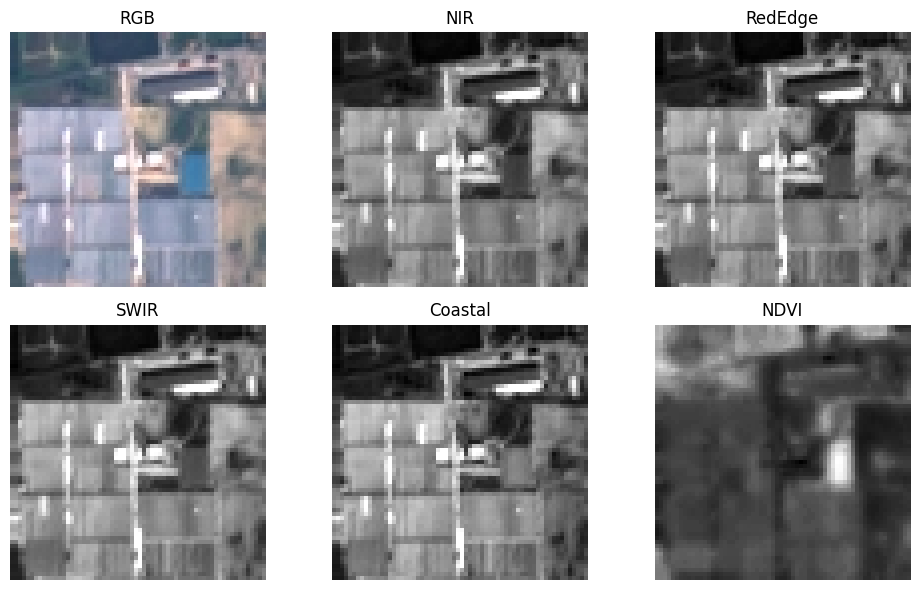

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load RGB image (0–255)
img = cv2.imread(r"D:\Code\satclip\notebooks\satclip-paper\image.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

R, G, B = img[..., 0], img[..., 1], img[..., 2]

# --- Fake spectral bands ---
bands = {}

# Near Infrared (NIR) – vegetation pops
bands["NIR"] = 0.6 * G + 0.4 * R

# Red Edge – slightly shifted NIR
bands["RedEdge"] = 0.5 * G + 0.3 * R + 0.2 * B

# Shortwave Infrared (SWIR) – drier / urban emphasis
bands["SWIR"] = 0.5 * R + 0.5 * B

# Coastal / Aerosol (blue-heavy)
bands["Coastal"] = B

# Vegetation Index (NDVI-like fake)
bands["NDVI"] = (bands["NIR"] - R) / (bands["NIR"] + R + 1e-6)

# Normalize all bands to [0,1]
for k in bands:
    b = bands[k]
    b = (b - b.min()) / (b.max() - b.min() + 1e-6)
    bands[k] = b

# --- Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

axes[0].imshow(img)
axes[0].set_title("RGB")

for i, (name, band) in enumerate(bands.items(), start=1):
    axes[i].imshow(band, cmap="gray")
    axes[i].set_title(name)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\R'
<>:6: SyntaxWarning: invalid escape sequence '\R'
C:\Users\sus14836\AppData\Local\Temp\ipykernel_56160\518992383.py:6: SyntaxWarning: invalid escape sequence '\R'
  df = pd.read_csv("E:\Results\GRIID\embs\index.csv")  # columns: lat, lon


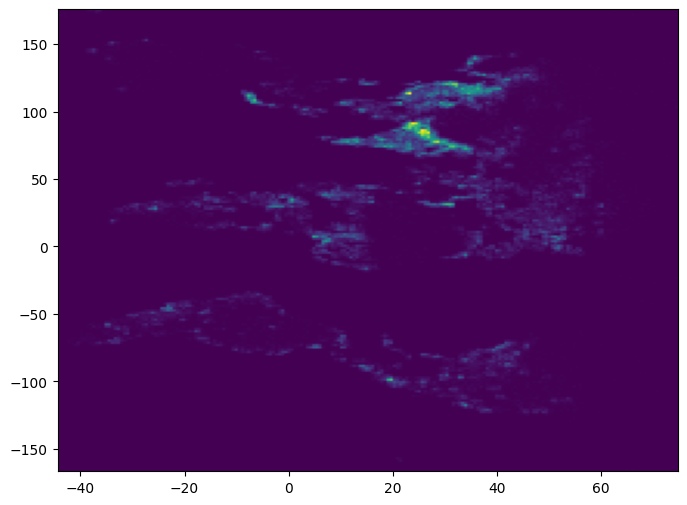

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("E:\Results\GRIID\embs\index.csv")  # columns: lat, lon

lat = df["lon"].values
lon = df["lat"].values

# Define grid
bins = 200  # increase for finer heatmap
heatmap, xedges, yedges = np.histogram2d(lat, lon, bins=bins)

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(
    heatmap.T,
    origin="lower",
    aspect="auto",
    extent=[lat.min(), lat.max(), lon.min(), lon.max()]
)
# plt.colorbar(label="Density")
# plt.xlabel("Latitude")
# plt.ylabel("Longitude")
# plt.title("Sampling Density Heatmap")
# plt.show()

In [26]:
import pandas as pd
from folium import Map
from folium.plugins import HeatMap

# Load data
df = pd.read_csv(r"E:\Results\GRIID\embs\index.csv")

# Convert to list of [lat, lon]
points = df[["lon", "lat"]].dropna().values.tolist()

# Center map
center = [df["lat"].mean(), df["lon"].mean()]

m = Map(location=center, zoom_start=5)

HeatMap(points, radius=8, blur=15).add_to(m)

m.save("E:/heatmap.html")

In [22]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)

   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sus14836\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


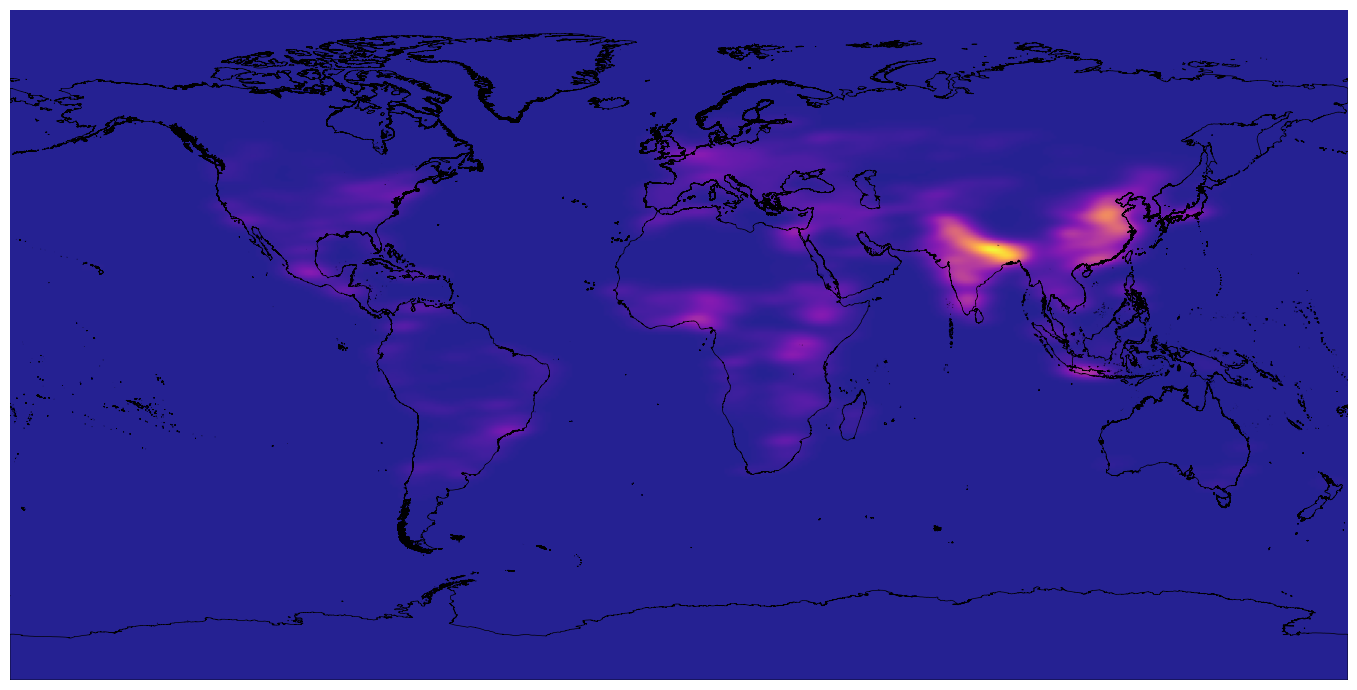

In [30]:
land = r"E:\Data\Global\World\land-polygons-complete-4326\land_polygons.shp"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.stats import gaussian_kde

# --- Load data ---
df = pd.read_csv(r"E:\Results\GRIID\embs\index.csv")  # columns: lat, lon
df = df.dropna(subset=["lat", "lon"])

lat = df["lon"].values
lon = df["lat"].values

# --- Load land shapefile ---
land = gpd.read_file(land)

# --- KDE (smooth density like your image) ---
xy = np.vstack([lon, lat])
kde = gaussian_kde(xy, bw_method=0.05)  # tweak bandwidth

# Create grid
xmin, xmax = -180, 180
ymin, ymax = -90, 90

xx, yy = np.mgrid[xmin:xmax:500j, ymin:ymax:250j]
grid_coords = np.vstack([xx.ravel(), yy.ravel()])

zz = kde(grid_coords).reshape(xx.shape)

# Log scale (important for that "glow" look)
zz = np.log1p(zz)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 7))

# Heatmap
im = ax.imshow(
    zz.T,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="plasma",
    alpha=0.9
)

# Overlay land boundaries
land.boundary.plot(ax=ax, color="black", linewidth=0.5)

# Styling
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import gaussian_kde

# --- Load data ---
df = df.dropna(subset=["lat", "lon"])

lon = df["lon"].values
lat = df["lat"].values

# --- Load land shapefile ---
# land = gpd.read_file("land.shp")
land_union = land.unary_union  # merge all polygons

# --- KDE ---
xy = np.vstack([lon, lat])
kde = gaussian_kde(xy, bw_method=0.05)

# Grid
xmin, xmax = -180, 180
ymin, ymax = -90, 90

nx, ny = 600, 300
xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, nx),
    np.linspace(ymin, ymax, ny)
)

coords = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(coords).reshape(xx.shape)

# Log scale for glow
zz = np.log1p(zz)

# --- MASK oceans ---
mask = np.zeros_like(zz, dtype=bool)

for i in range(nx):
    for j in range(ny):
        pt = Point(xx[j, i], yy[j, i])
        if not land_union.contains(pt):
            mask[j, i] = True

zz = np.ma.masked_array(zz, mask=mask)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 7))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Heatmap (only land visible)
im = ax.pcolormesh(
    xx, yy, zz,
    shading='auto',
    cmap='plasma'
)

# Optional: faint land outline
land.boundary.plot(ax=ax, color="black", linewidth=0.3, alpha=0.3)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.axis("off")

plt.tight_layout()
plt.show()

C:\Users\sus14836\AppData\Local\Temp\ipykernel_56160\167129289.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land_union = land.unary_union  # merge all polygons


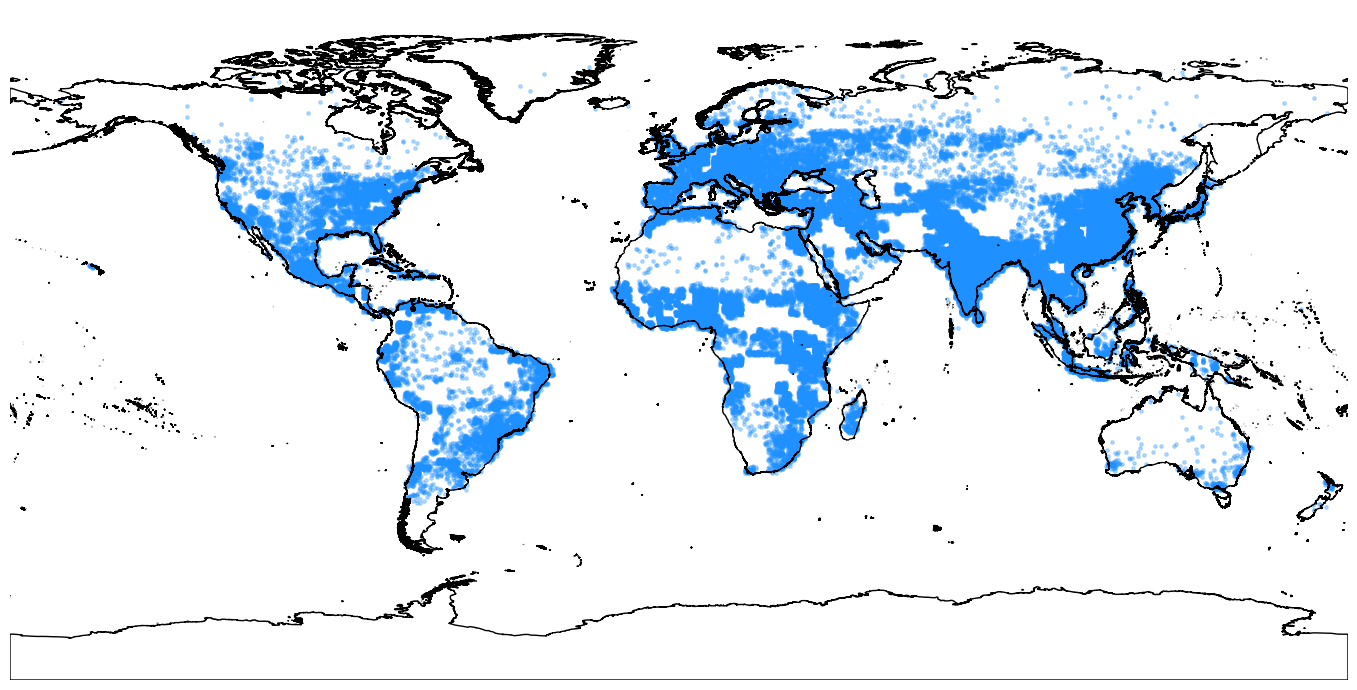

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

land = r"E:\Data\Global\World\land-polygons-complete-4326\land_polygons.shp"
# Load data
df = pd.read_csv(r"E:\Results\GRIID\embs\index.csv")  # lat, lon

# Load land shapefile
land = gpd.read_file(land)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Land boundary (clean outline)
land.boundary.plot(ax=ax, color="black", linewidth=1)

# Scatter points
# ax.scatter(
#     df["lat"],
#     df["lon"],
#     s=8,                 # point size
#     alpha=0.5,           # transparency = density effect
# )
ax.scatter(
    df["lat"],
    df["lon"],
    s=6,
    alpha=0.3,
    c="dodgerblue"
)
# ax.hexbin(
#     df["lat"], df["lon"],
#     gridsize=100,
#     cmap="Blues",
#     bins="log",
#     mincnt=1
# )

# Clean look
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.axis("off")

plt.tight_layout()
plt.show()